In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

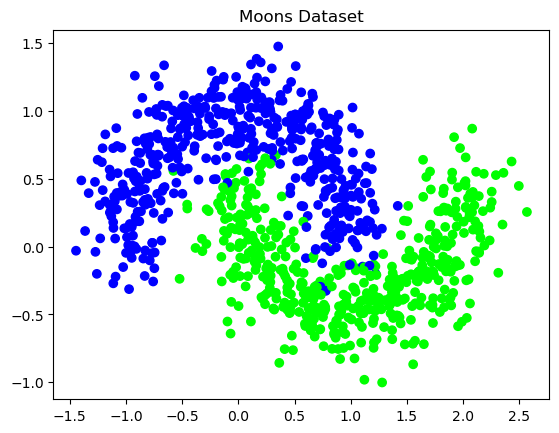

In [83]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.title("Moons Dataset")
plt.show()


In [84]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [85]:
scaler = StandardScaler()

In [86]:
scaler.fit(X_train)

StandardScaler()

In [87]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [89]:
# model.compile(optimizer=tf.keras.optimizers.SGD(momentum = 0.8),loss='binary_crossentropy',metrics=['accuracy'])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [90]:
history = model.fit(x=X_train,y=y_train,validation_data=(X_test,y_test),epochs=200,verbose=1)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6105 - loss: 0.6619 - val_accuracy: 0.8100 - val_loss: 0.6070
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8347 - loss: 0.5824 - val_accuracy: 0.8050 - val_loss: 0.5345
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8297 - loss: 0.5070 - val_accuracy: 0.8100 - val_loss: 0.4591
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8457 - loss: 0.4222 - val_accuracy: 0.8200 - val_loss: 0.3928
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8450 - loss: 0.3815 - val_accuracy: 0.8450 - val_loss: 0.3457
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8504 - loss: 0.3308 - val_accuracy: 0.8600 - val_loss: 0.3133
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8760 - loss: 0.2880 - val_accuracy: 0.8750 - val_loss: 0.2921
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8776 - loss: 0.2716 - val_accuracy: 0.8800 - v

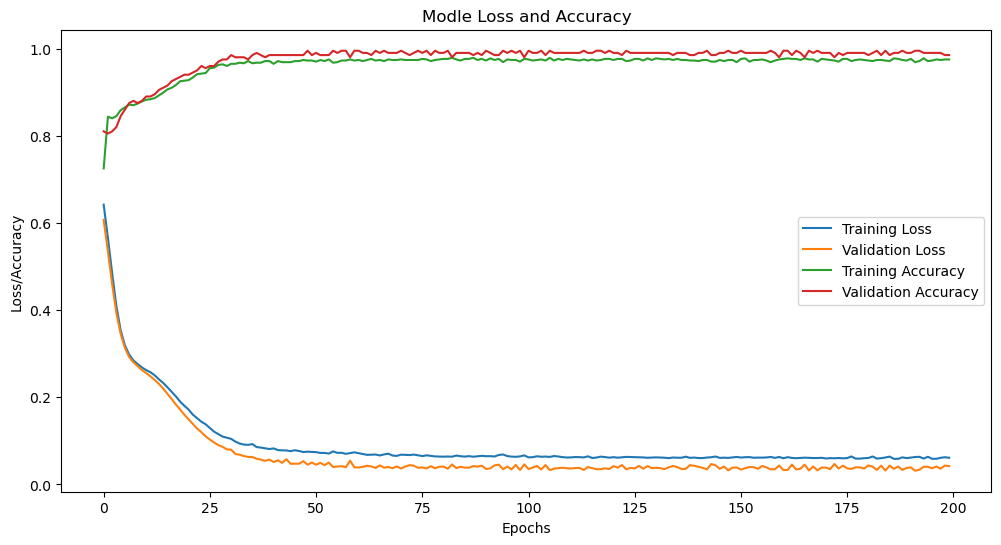

In [91]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'],label = 'Training Loss')
plt.plot(history.history['val_loss'],label = 'Validation Loss')
plt.plot(history.history['accuracy'],label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Modle Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


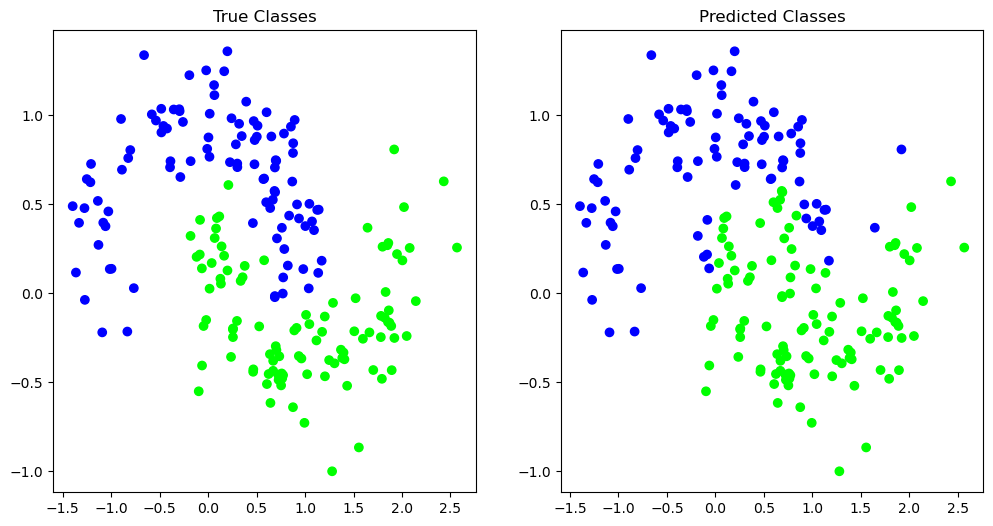

In [92]:
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1) #subplot(nrows, ncols, index, **kwargs)
plt.scatter(X_test[:,0],X_test[:,1],c = y_test,cmap='brg')
plt.title('True Classes')
plt.subplot(1,2,2)
plt.scatter(X_test[:,0],X_test[:,1],c = y_pred,cmap='brg')
plt.title('Predicted Classes')
plt.show()

In [93]:
from sklearn.metrics import log_loss

# Predict probabilities for the test set (since this is binary classification)
y_pred_prob = model.predict(X_test_scaled).flatten()  # Flatten to make sure it's a 1D array

# Calculate binary cross-entropy (log loss)
loss = log_loss(y_test, y_pred_prob)
print(f'Binary Cross-Entropy Loss: {loss}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Binary Cross-Entropy Loss: 0.5839050410742421


2070/2070 ━━━━━━━━━━━━━━━━━━━━ 0s 197us/step


/var/folders/rz/h60gmgln7qvgnmg0h1bwvk180000gn/T/ipykernel_45039/3539070050.py:28: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', marker='x', s=50, label='Test Data')


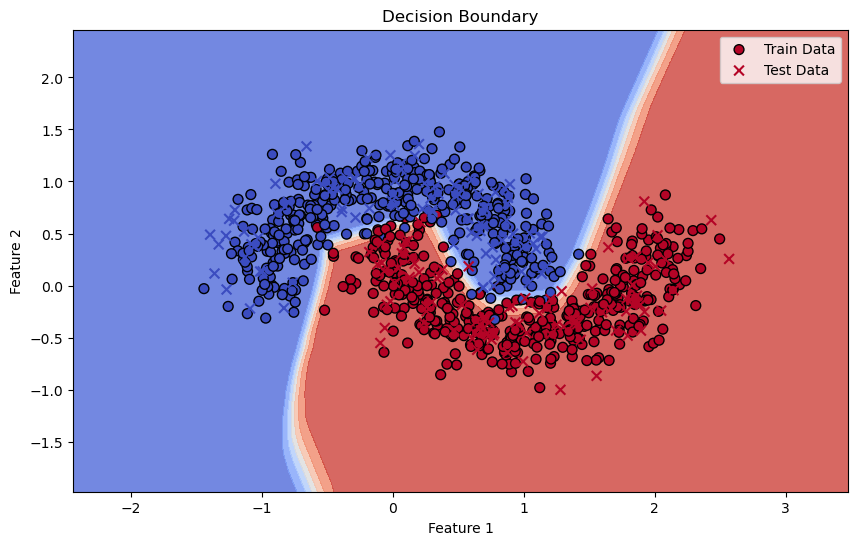

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a mesh grid
h = 0.02  # step size for the mesh grid
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

# Create the mesh grid
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Flatten the grid so we can pass it to the model
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict the class labels for each point in the grid
y_pred_grid = model.predict(grid_points)

# Reshape the predictions back into the shape of the mesh grid
y_pred_grid = y_pred_grid.reshape(xx.shape)

# Plot the decision boundary by coloring the regions
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, y_pred_grid, alpha=0.8, cmap='coolwarm')

# Plot the original data points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', marker='o', s=50, label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', marker='x', s=50, label='Test Data')

plt.title("Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()
